# 📊 Evaluation - Sentiment Analysis Blu by BCA Digital

Notebook ini melakukan evaluasi mendalam terhadap model terbaik:
- Confusion Matrix
- Classification Report (Precision, Recall, F1)
- ROC-AUC Curve
- Error Analysis (salah prediksi)
- Feature Importance (kata-kata paling berpengaruh)

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
print('Library berhasil diimport!')

Library berhasil diimport!


## 2. Load Model & Data Prediksi

In [9]:
# Load best model
with open('../data/best_model_bundle.pkl', 'rb') as f:
    model_data = pickle.load(f)

best_model = model_data['vectorizer']
best_model_name = model_data['model_name']
print(f'Model dimuat: {best_model_name}')

# Load test predictions
pred_df = pd.read_csv('../data/test_predictions.csv')
print(f'Jumlah data test: {len(pred_df)}')
pred_df.head()

Model dimuat: Logistic Regression
Jumlah data test: 3636


,final_content,true_label,predicted_label,is_correct
0,verifikasi email susah banget suruh disebutin ...,negatif,negatif,True
1,autodebit posko,positif,positif,True
2,ui berat suka force close android,negatif,negatif,True
3,baru lola hapusin lai memori d hapusin hp d re...,negatif,negatif,True
4,kasih gratis biaya transfer kasih bintang nih,positif,positif,True


In [10]:
y_test = pred_df['true_label']
y_pred = pred_df['predicted_label']
LABELS = sorted(y_test.unique().tolist())
print(f'Kelas: {LABELS}')

Kelas: ['negatif', 'positif']


## 3. Classification Report

In [11]:
print(f'{'='*55}')
print(f'  Evaluation: {best_model_name}')
print(f'{'='*55}')
print(f'  Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%')
print(f'{'='*55}\n')
print(classification_report(y_test, y_pred, target_names=LABELS))

SyntaxError: f-string: expecting '}' (2279472268.py, line 1)

## 4. Confusion Matrix

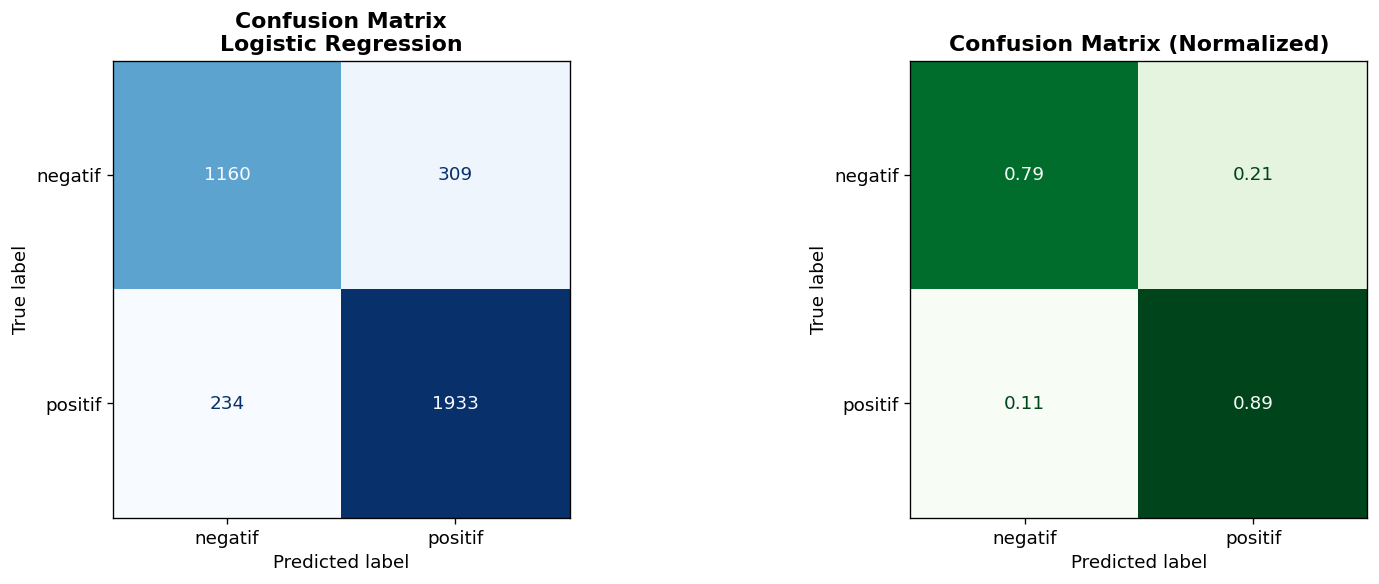


Interpretasi:
  negatif: 1160/1469 benar (79.0%)
  positif: 1933/2167 benar (89.2%)


In [12]:
cm = confusion_matrix(y_test, y_pred, labels=LABELS)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw count
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)
disp1.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix\n{best_model_name}', fontweight='bold')

# Normalized
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
disp2 = ConfusionMatrixDisplay(confusion_matrix=np.round(cm_norm, 2), display_labels=LABELS)
disp2.plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Confusion Matrix (Normalized)', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nInterpretasi:')
for i, label in enumerate(LABELS):
    tp = cm[i, i]
    total = cm[i].sum()
    print(f'  {label}: {tp}/{total} benar ({tp/total*100:.1f}%)')

## 5. ROC-AUC Curve (One-vs-Rest)

In [13]:
# Binarize labels untuk ROC (One-vs-Rest)
TEXT_COL = pred_df.columns[0]  # kolom teks pertama
X_test_texts = pred_df[TEXT_COL]

# Cek apakah model mendukung predict_proba
has_proba = hasattr(best_model, 'predict_proba')

if has_proba:
    y_score = best_model.predict_proba(X_test_texts)
    y_bin = label_binarize(y_test, classes=LABELS)

    fig, ax = plt.subplots(figsize=(8, 6))
    colors = ['#E74C3C', '#F39C12', '#2ECC71']

    for i, (label, color) in enumerate(zip(LABELS, colors)):
        if y_bin.shape[1] > 1:
            fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
            roc_auc = auc(fpr, tpr)
            ax.plot(fpr, tpr, color=color, lw=2,
                    label=f'{label} (AUC = {roc_auc:.3f})')

    ax.plot([0,1], [0,1], 'k--', lw=1, label='Random')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC-AUC Curve ({best_model_name})', fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('../data/roc_auc_curve.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f'ℹ️ {best_model_name} tidak mendukung predict_proba (SVM/LinearSVC).')
    print('   Gunakan decision_function atau pilih model lain untuk ROC curve.')

ℹ️ Logistic Regression tidak mendukung predict_proba (SVM/LinearSVC).
   Gunakan decision_function atau pilih model lain untuk ROC curve.


## 6. Error Analysis - Review yang Salah Diprediksi

In [ ]:
errors = pred_df[pred_df['is_correct'] == False].copy()
print(f'Total salah prediksi: {len(errors)} dari {len(pred_df)} ({len(errors)/len(pred_df)*100:.1f}%)')
print()

# Breakdown error per true label
print('Error per True Label:')
print(errors.groupby(['true_label', 'predicted_label']).size().reset_index(name='count').to_string(index=False))

In [ ]:
# Tampilkan contoh error per kategori
for true_label in LABELS:
    subset = errors[errors['true_label'] == true_label]
    if len(subset) == 0:
        continue
    print(f'\n{'='*60}')
    print(f'TRUE: {true_label.upper()} → Diprediksi salah ({len(subset)} kasus)')
    print('='*60)
    for _, row in subset.head(5).iterrows():
        print(f'  → Prediksi: [{row["predicted_label"]}]')
        print(f'    Teks: "{str(row[pred_df.columns[0]])[:120]}..."')
        print()

## 7. Top Feature Words per Kelas

In [ ]:
# Ekstrak kata-kata paling penting per kelas (hanya untuk model dengan coef_)
clf = best_model.named_steps['clf']
tfidf = best_model.named_steps['tfidf']
feature_names = np.array(tfidf.get_feature_names_out())

if hasattr(clf, 'coef_'):
    fig, axes = plt.subplots(1, len(LABELS), figsize=(5*len(LABELS), 5))
    if len(LABELS) == 1:
        axes = [axes]

    colors_map = {'negatif': '#E74C3C', 'netral': '#F39C12', 'positif': '#2ECC71'}

    for i, (label, ax) in enumerate(zip(clf.classes_, axes)):
        coef = clf.coef_[i] if clf.coef_.ndim > 1 else clf.coef_[0]
        top_idx = np.argsort(coef)[-15:][::-1]
        top_words = feature_names[top_idx]
        top_scores = coef[top_idx]

        color = colors_map.get(label, '#3498DB')
        ax.barh(range(len(top_words)), top_scores, color=color, alpha=0.8)
        ax.set_yticks(range(len(top_words)))
        ax.set_yticklabels(top_words, fontsize=10)
        ax.invert_yaxis()
        ax.set_title(f'Top Kata: {label.upper()}', fontweight='bold', color=color)
        ax.set_xlabel('Koefisien TF-IDF')
        ax.grid(axis='x', alpha=0.3)

    plt.suptitle(f'Kata Paling Berpengaruh per Kelas Sentimen\n({best_model_name})',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../data/feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f'ℹ️ {best_model_name} tidak memiliki atribut coef_.')
    print('   Coba gunakan Logistic Regression atau SVM untuk analisis fitur ini.')

## 8. Ringkasan Evaluasi

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

summary = {
    'Model': best_model_name,
    'Accuracy': f'{accuracy_score(y_test, y_pred)*100:.2f}%',
    'Precision (weighted)': f'{precision_score(y_test, y_pred, average="weighted"):.4f}',
    'Recall (weighted)': f'{recall_score(y_test, y_pred, average="weighted"):.4f}',
    'F1 Score (weighted)': f'{f1_score(y_test, y_pred, average="weighted"):.4f}',
    'Total Test Data': len(y_test),
    'Correct Predictions': (y_test == y_pred).sum(),
    'Wrong Predictions': (y_test != y_pred).sum()
}

print('📋 RINGKASAN EVALUASI MODEL')
print('='*45)
for k, v in summary.items():
    print(f'  {k:<30}: {v}')
print('='*45)

# Simpan summary
pd.DataFrame([summary]).to_csv('../data/evaluation_summary.csv', index=False)
print('\n✅ Ringkasan disimpan ke: ../data/evaluation_summary.csv')